# Ml Clustering
In this notebook, we will try to find groups for the customers that were not assinged to any group in 3_user_segmentation.ipynb.

In [195]:
import pandas as pd
import seaborn as sns

In [196]:
users_features = pd.read_csv('data/users_no_group.csv')
users_features_all = pd.read_csv('data/user_features.csv')

In [197]:
users_features

,user_id,gender,married,has_children,home_country,tenure,age,seats_avg,checked_bags_avg,total_trips,cancellation_rate,unique_flight_destination,taken_flights,frequent_destinations,sessions_booking_rate,discount_booking_rate,booked_flight,booked_hotel
0,94883,F,True,False,usa,1509,54,1.5,0.500000,2,0.0,2.0,2,1.0,0.250,0.0,True,True
1,101486,F,True,True,usa,1499,53,1.0,0.000000,2,0.0,1.0,2,0.5,0.250,0.0,True,True
2,101961,F,True,False,usa,1499,45,1.0,0.400000,5,0.0,5.0,5,1.0,0.625,0.2,True,True
3,118043,F,False,True,usa,1478,53,2.0,1.000000,5,0.0,3.0,5,0.6,0.625,0.6,True,True
4,153982,F,False,True,canada,1438,47,1.0,0.333333,3,0.0,3.0,3,1.0,0.375,0.0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4617,777366,F,False,False,usa,1068,50,1.0,0.000000,1,0.0,1.0,1,1.0,0.125,0.0,True,True
4618,780167,F,True,True,usa,1067,51,1.5,0.000000,2,0.0,2.0,2,1.0,0.250,0.5,True,True
4619,785186,F,True,True,usa,1065,46,1.0,0.000000,2,0.0,2.0,2,1.0,0.250,0.0,True,True
4620,792549,F,False,False,usa,1062,48,1.0,0.500000,4,0.0,4.0,4,1.0,0.500,0.0,True,True


# Preprocessing

### Gender

In [198]:
users_features['gender'].value_counts()

gender
F    4094
M     521
O       7
Name: count, dtype: int64

In [199]:
users_features['gender'] = users_features['gender'].map({"F":0, "M":1, "O":2})

## Home country

In [200]:
users_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    4622 non-null   int64  
 1   gender                     4622 non-null   int64  
 2   married                    4622 non-null   bool   
 3   has_children               4622 non-null   bool   
 4   home_country               4622 non-null   str    
 5   tenure                     4622 non-null   int64  
 6   age                        4622 non-null   int64  
 7   seats_avg                  4406 non-null   float64
 8   checked_bags_avg           4406 non-null   float64
 9   total_trips                4622 non-null   int64  
 10  cancellation_rate          4622 non-null   float64
 11  unique_flight_destination  4430 non-null   float64
 12  taken_flights              4622 non-null   int64  
 13  frequent_destinations      4430 non-null   float64
 14  ses

In [201]:
users_features['home_country'].value_counts()

home_country
usa       3821
canada     801
Name: count, dtype: int64

In [202]:
users_features['home_country'] = users_features['home_country'].map({"usa":0, "canada":1})

## Booleans in int

In [203]:
bool_cols = users_features.select_dtypes(include=['bool']).columns

In [204]:
users_features[bool_cols] = users_features[bool_cols].astype(int)

In [205]:
users_features

,user_id,gender,married,has_children,home_country,tenure,age,seats_avg,checked_bags_avg,total_trips,cancellation_rate,unique_flight_destination,taken_flights,frequent_destinations,sessions_booking_rate,discount_booking_rate,booked_flight,booked_hotel
0,94883,0,1,0,0,1509,54,1.5,0.500000,2,0.0,2.0,2,1.0,0.250,0.0,1,1
1,101486,0,1,1,0,1499,53,1.0,0.000000,2,0.0,1.0,2,0.5,0.250,0.0,1,1
2,101961,0,1,0,0,1499,45,1.0,0.400000,5,0.0,5.0,5,1.0,0.625,0.2,1,1
3,118043,0,0,1,0,1478,53,2.0,1.000000,5,0.0,3.0,5,0.6,0.625,0.6,1,1
4,153982,0,0,1,1,1438,47,1.0,0.333333,3,0.0,3.0,3,1.0,0.375,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4617,777366,0,0,0,0,1068,50,1.0,0.000000,1,0.0,1.0,1,1.0,0.125,0.0,1,1
4618,780167,0,1,1,0,1067,51,1.5,0.000000,2,0.0,2.0,2,1.0,0.250,0.5,1,1
4619,785186,0,1,1,0,1065,46,1.0,0.000000,2,0.0,2.0,2,1.0,0.250,0.0,1,1
4620,792549,0,0,0,0,1062,48,1.0,0.500000,4,0.0,4.0,4,1.0,0.500,0.0,1,1


## Nan Values


In [206]:
users_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    4622 non-null   int64  
 1   gender                     4622 non-null   int64  
 2   married                    4622 non-null   int64  
 3   has_children               4622 non-null   int64  
 4   home_country               4622 non-null   int64  
 5   tenure                     4622 non-null   int64  
 6   age                        4622 non-null   int64  
 7   seats_avg                  4406 non-null   float64
 8   checked_bags_avg           4406 non-null   float64
 9   total_trips                4622 non-null   int64  
 10  cancellation_rate          4622 non-null   float64
 11  unique_flight_destination  4430 non-null   float64
 12  taken_flights              4622 non-null   int64  
 13  frequent_destinations      4430 non-null   float64
 14  ses

### Seats avg

In [207]:
users_features['seats_avg'] = users_features['seats_avg'].fillna(0)

### checked bags avg

<Axes: xlabel='checked_bags_avg'>

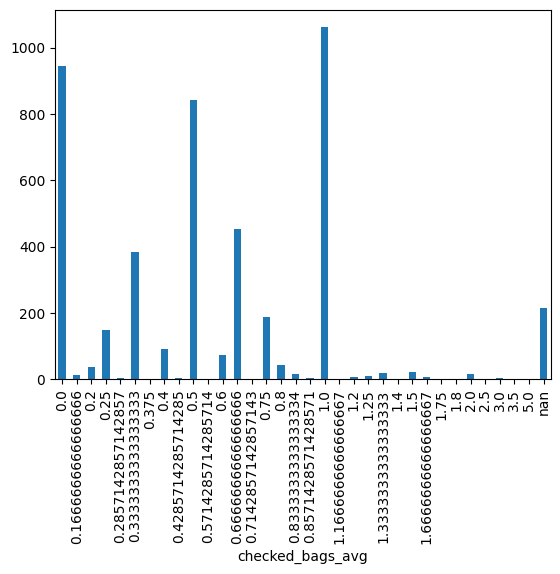

In [208]:
users_features['checked_bags_avg'].value_counts(dropna=False).sort_index().plot(kind='bar')

In [209]:
users_features['bags_per_seat_avg']  = users_features['checked_bags_avg']/ users_features['seats_avg']

In [210]:
users_features['bags_per_seat_avg'].value_counts(dropna=False)

bags_per_seat_avg
0.000000    944
1.000000    826
0.500000    813
0.333333    411
0.666667    370
NaN         216
0.250000    204
0.750000    158
0.600000    121
0.400000    107
0.200000     73
0.800000     58
0.400000     37
0.200000     30
0.166667     24
0.333333     23
0.285714     20
0.285714     19
0.166667     16
0.833333     14
0.666667     14
0.428571     13
0.714286     12
0.428571     10
0.571429     10
0.125000      7
0.800000      6
0.142857      5
0.555556      4
0.857143      4
0.444444      4
0.375000      3
0.444444      3
0.142857      3
0.166667      3
0.222222      3
0.571429      3
0.375000      3
0.142857      3
0.857143      3
0.125000      2
0.111111      2
0.222222      2
0.111111      2
0.428571      2
0.100000      2
0.625000      1
0.875000      1
0.625000      1
0.875000      1
0.545455      1
0.454545      1
0.714286      1
0.090909      1
0.272727      1
0.111111      1
Name: count, dtype: int64

In [211]:
users_features.drop(columns=['checked_bags_avg'],inplace=True)

In [212]:
users_features["bags_per_seat_avg"] = users_features["bags_per_seat_avg"].fillna(users_features["bags_per_seat_avg"].mean())

### Cancelation rate

In [213]:
users_features['cancellation_rate']  = users_features['cancellation_rate'].fillna(users_features['cancellation_rate'].mean())

In [214]:
users_features['unique_flight_destination'] = users_features['unique_flight_destination'].fillna(users_features['unique_flight_destination'].mean())

### Frequent destination

In [215]:
users_features

,user_id,gender,married,has_children,home_country,tenure,age,seats_avg,total_trips,cancellation_rate,unique_flight_destination,taken_flights,frequent_destinations,sessions_booking_rate,discount_booking_rate,booked_flight,booked_hotel,bags_per_seat_avg
0,94883,0,1,0,0,1509,54,1.5,2,0.0,2.0,2,1.0,0.250,0.0,1,1,0.333333
1,101486,0,1,1,0,1499,53,1.0,2,0.0,1.0,2,0.5,0.250,0.0,1,1,0.000000
2,101961,0,1,0,0,1499,45,1.0,5,0.0,5.0,5,1.0,0.625,0.2,1,1,0.400000
3,118043,0,0,1,0,1478,53,2.0,5,0.0,3.0,5,0.6,0.625,0.6,1,1,0.500000
4,153982,0,0,1,1,1438,47,1.0,3,0.0,3.0,3,1.0,0.375,0.0,1,1,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4617,777366,0,0,0,0,1068,50,1.0,1,0.0,1.0,1,1.0,0.125,0.0,1,1,0.000000
4618,780167,0,1,1,0,1067,51,1.5,2,0.0,2.0,2,1.0,0.250,0.5,1,1,0.000000
4619,785186,0,1,1,0,1065,46,1.0,2,0.0,2.0,2,1.0,0.250,0.0,1,1,0.000000
4620,792549,0,0,0,0,1062,48,1.0,4,0.0,4.0,4,1.0,0.500,0.0,1,1,0.500000


frequent_destinations is redundant as we have unique_flight_destination and taken_flights. We used it for the user segementation but wont be necessary for the clustering.

In [216]:
users_features.drop(columns = ['frequent_destinations'], inplace=True)

In [217]:
users_features

,user_id,gender,married,has_children,home_country,tenure,age,seats_avg,total_trips,cancellation_rate,unique_flight_destination,taken_flights,sessions_booking_rate,discount_booking_rate,booked_flight,booked_hotel,bags_per_seat_avg
0,94883,0,1,0,0,1509,54,1.5,2,0.0,2.0,2,0.250,0.0,1,1,0.333333
1,101486,0,1,1,0,1499,53,1.0,2,0.0,1.0,2,0.250,0.0,1,1,0.000000
2,101961,0,1,0,0,1499,45,1.0,5,0.0,5.0,5,0.625,0.2,1,1,0.400000
3,118043,0,0,1,0,1478,53,2.0,5,0.0,3.0,5,0.625,0.6,1,1,0.500000
4,153982,0,0,1,1,1438,47,1.0,3,0.0,3.0,3,0.375,0.0,1,1,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4617,777366,0,0,0,0,1068,50,1.0,1,0.0,1.0,1,0.125,0.0,1,1,0.000000
4618,780167,0,1,1,0,1067,51,1.5,2,0.0,2.0,2,0.250,0.5,1,1,0.000000
4619,785186,0,1,1,0,1065,46,1.0,2,0.0,2.0,2,0.250,0.0,1,1,0.000000
4620,792549,0,0,0,0,1062,48,1.0,4,0.0,4.0,4,0.500,0.0,1,1,0.500000


### Discount booking rate

In [218]:
users_features['discount_booking_rate'].value_counts(dropna=False)

discount_booking_rate
0.000000    2015
0.500000     667
0.333333     574
0.250000     380
1.000000     321
0.666667     203
0.200000     183
0.400000     120
0.166667      59
0.750000      46
0.600000      30
0.142857       7
0.285714       6
0.800000       5
0.571429       2
0.714286       1
0.428571       1
0.857143       1
0.125000       1
Name: count, dtype: int64

In [219]:
users_features['discount_booking_rate'] = users_features['discount_booking_rate'].fillna(users_features['discount_booking_rate'].mean())

In [220]:
users_features.isna().sum()

user_id                      0
gender                       0
married                      0
has_children                 0
home_country                 0
tenure                       0
age                          0
seats_avg                    0
total_trips                  0
cancellation_rate            0
unique_flight_destination    0
taken_flights                0
sessions_booking_rate        0
discount_booking_rate        0
booked_flight                0
booked_hotel                 0
bags_per_seat_avg            0
dtype: int64

In [223]:
users_features

,gender,married,has_children,home_country,tenure,age,seats_avg,total_trips,cancellation_rate,unique_flight_destination,taken_flights,sessions_booking_rate,discount_booking_rate,booked_flight,booked_hotel,bags_per_seat_avg
0,0,1,0,0,1509,54,1.5,2,0.0,2.0,2,0.250,0.0,1,1,0.333333
1,0,1,1,0,1499,53,1.0,2,0.0,1.0,2,0.250,0.0,1,1,0.000000
2,0,1,0,0,1499,45,1.0,5,0.0,5.0,5,0.625,0.2,1,1,0.400000
3,0,0,1,0,1478,53,2.0,5,0.0,3.0,5,0.625,0.6,1,1,0.500000
4,0,0,1,1,1438,47,1.0,3,0.0,3.0,3,0.375,0.0,1,1,0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4617,0,0,0,0,1068,50,1.0,1,0.0,1.0,1,0.125,0.0,1,1,0.000000
4618,0,1,1,0,1067,51,1.5,2,0.0,2.0,2,0.250,0.5,1,1,0.000000
4619,0,1,1,0,1065,46,1.0,2,0.0,2.0,2,0.250,0.0,1,1,0.000000
4620,0,0,0,0,1062,48,1.0,4,0.0,4.0,4,0.500,0.0,1,1,0.500000


In [222]:
users_features.drop(columns=['user_id'], inplace=True)

## Scaling


In [224]:
# We will use StandardScaler to scale the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_users_features = scaler.fit_transform(users_features)



In [225]:
scaled_users_features

array([[-0.3565674 ,  1.14954187, -0.68087043, ...,  0.22141377,
         0.13355703, -0.41799241],
       [-0.3565674 ,  1.14954187,  1.46870822, ...,  0.22141377,
         0.13355703, -1.41470737],
       [-0.3565674 ,  1.14954187, -0.68087043, ...,  0.22141377,
         0.13355703, -0.21864942],
       ...,
       [-0.3565674 ,  1.14954187,  1.46870822, ...,  0.22141377,
         0.13355703, -1.41470737],
       [-0.3565674 , -0.86991177, -0.68087043, ...,  0.22141377,
         0.13355703,  0.08036507],
       [-0.3565674 ,  1.14954187,  1.46870822, ...,  0.22141377,
         0.13355703, -1.41470737]], shape=(4622, 16))

# K - Means

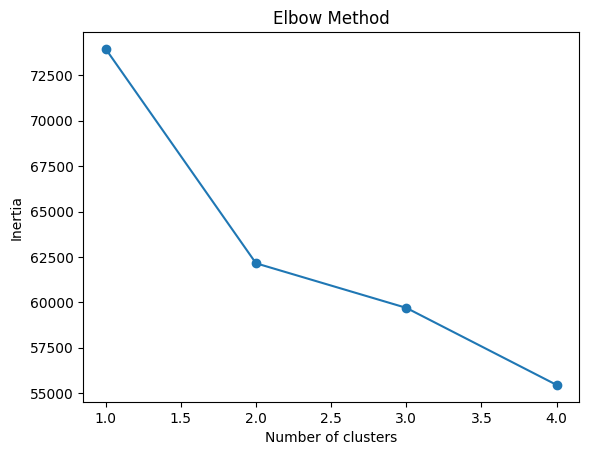

In [226]:
# We will use the elbow method to find the optimal number of clusters
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 5):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_users_features)
    inertia.append(kmeans.inertia_)
plt.plot(range(1, 5), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [250]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(scaled_users_features)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [251]:
kmeans.labels_

array([1, 1, 0, ..., 1, 0, 1], shape=(4622,), dtype=int32)

In [252]:
users_features

,gender,married,has_children,home_country,tenure,age,seats_avg,total_trips,cancellation_rate,unique_flight_destination,taken_flights,sessions_booking_rate,discount_booking_rate,booked_flight,booked_hotel,bags_per_seat_avg,cluster
0,0,1,0,0,1509,54,1.5,2,0.0,2.0,2,0.250,0.0,1,1,0.333333,1
1,0,1,1,0,1499,53,1.0,2,0.0,1.0,2,0.250,0.0,1,1,0.000000,1
2,0,1,0,0,1499,45,1.0,5,0.0,5.0,5,0.625,0.2,1,1,0.400000,0
3,0,0,1,0,1478,53,2.0,5,0.0,3.0,5,0.625,0.6,1,1,0.500000,0
4,0,0,1,1,1438,47,1.0,3,0.0,3.0,3,0.375,0.0,1,1,0.333333,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4617,0,0,0,0,1068,50,1.0,1,0.0,1.0,1,0.125,0.0,1,1,0.000000,1
4618,0,1,1,0,1067,51,1.5,2,0.0,2.0,2,0.250,0.5,1,1,0.000000,1
4619,0,1,1,0,1065,46,1.0,2,0.0,2.0,2,0.250,0.0,1,1,0.000000,1
4620,0,0,0,0,1062,48,1.0,4,0.0,4.0,4,0.500,0.0,1,1,0.500000,0


In [253]:
# We will add the cluster labels to the original dataframe
users_features['cluster'] = kmeans.labels_

In [254]:
users_features

,gender,married,has_children,home_country,tenure,age,seats_avg,total_trips,cancellation_rate,unique_flight_destination,taken_flights,sessions_booking_rate,discount_booking_rate,booked_flight,booked_hotel,bags_per_seat_avg,cluster
0,0,1,0,0,1509,54,1.5,2,0.0,2.0,2,0.250,0.0,1,1,0.333333,1
1,0,1,1,0,1499,53,1.0,2,0.0,1.0,2,0.250,0.0,1,1,0.000000,1
2,0,1,0,0,1499,45,1.0,5,0.0,5.0,5,0.625,0.2,1,1,0.400000,0
3,0,0,1,0,1478,53,2.0,5,0.0,3.0,5,0.625,0.6,1,1,0.500000,0
4,0,0,1,1,1438,47,1.0,3,0.0,3.0,3,0.375,0.0,1,1,0.333333,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4617,0,0,0,0,1068,50,1.0,1,0.0,1.0,1,0.125,0.0,1,1,0.000000,1
4618,0,1,1,0,1067,51,1.5,2,0.0,2.0,2,0.250,0.5,1,1,0.000000,1
4619,0,1,1,0,1065,46,1.0,2,0.0,2.0,2,0.250,0.0,1,1,0.000000,1
4620,0,0,0,0,1062,48,1.0,4,0.0,4.0,4,0.500,0.0,1,1,0.500000,0


In [255]:
users_features['cluster'].value_counts()

cluster
0    1949
1    1882
2     791
Name: count, dtype: int64

In [256]:
# Lets analyze the clusters
cluster_means = users_features.groupby('cluster').mean()
cluster_means

,gender,married,has_children,home_country,tenure,age,seats_avg,total_trips,cancellation_rate,unique_flight_destination,taken_flights,sessions_booking_rate,discount_booking_rate,booked_flight,booked_hotel,bags_per_seat_avg
cluster,,,,,,,,,,,,,,,,
0,0.000000,0.455618,0.279631,0.000000,1163.099025,45.680349,1.186550,3.941508,0.015726,3.304259,3.873781,0.480426,0.255630,1.000000,1.000000,0.485180
1,0.097768,0.420829,0.372476,0.151435,1159.290117,41.924017,1.046050,1.800213,0.046050,1.654077,1.688098,0.213045,0.280730,0.885228,0.956961,0.458547
2,0.443742,0.393173,0.275601,0.652339,1162.534766,44.841972,1.188408,3.847029,0.029777,3.199747,3.730721,0.471744,0.261095,1.000000,1.000000,0.478096


In [257]:
scaled_users_features

array([[-0.3565674 ,  1.14954187, -0.68087043, ...,  0.22141377,
         0.13355703, -0.41799241],
       [-0.3565674 ,  1.14954187,  1.46870822, ...,  0.22141377,
         0.13355703, -1.41470737],
       [-0.3565674 ,  1.14954187, -0.68087043, ...,  0.22141377,
         0.13355703, -0.21864942],
       ...,
       [-0.3565674 ,  1.14954187,  1.46870822, ...,  0.22141377,
         0.13355703, -1.41470737],
       [-0.3565674 , -0.86991177, -0.68087043, ...,  0.22141377,
         0.13355703,  0.08036507],
       [-0.3565674 ,  1.14954187,  1.46870822, ...,  0.22141377,
         0.13355703, -1.41470737]], shape=(4622, 16))

In [258]:
users_features.columns[:-1]

Index(['gender', 'married', 'has_children', 'home_country', 'tenure', 'age',
       'seats_avg', 'total_trips', 'cancellation_rate',
       'unique_flight_destination', 'taken_flights', 'sessions_booking_rate',
       'discount_booking_rate', 'booked_flight', 'booked_hotel',
       'bags_per_seat_avg'],
      dtype='str')

In [259]:
scaled_users_features_df

,gender,married,has_children,home_country,tenure,age,seats_avg,total_trips,cancellation_rate,unique_flight_destination,taken_flights,sessions_booking_rate,discount_booking_rate,booked_flight,booked_hotel,bags_per_seat_avg,cluster
0,-0.356567,1.149542,-0.680870,-0.457855,10.430284,1.129610,0.861611,-0.788407,-0.297497,-0.523252,-0.714234,-0.720491,-0.898716,0.221414,0.133557,-0.417992,1
1,-0.356567,1.149542,1.468708,-0.457855,10.130174,1.016566,-0.301657,-0.788407,-0.297497,-1.374835,-0.714234,-0.720491,-0.898716,0.221414,0.133557,-1.414707,1
2,-0.356567,1.149542,-0.680870,-0.457855,10.130174,0.112213,-0.301657,1.456828,-0.297497,2.031496,1.519318,1.529786,-0.224979,0.221414,0.133557,-0.218649,0
3,-0.356567,-0.869912,1.468708,-0.457855,9.499942,1.016566,2.024878,1.456828,-0.297497,0.328330,1.519318,1.529786,1.122494,0.221414,0.133557,0.080365,0
4,-0.356567,-0.869912,1.468708,2.184099,8.299502,0.338301,-0.301657,-0.039995,-0.297497,0.328330,0.030283,0.029602,-0.898716,0.221414,0.133557,-0.417992,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4617,-0.356567,-0.869912,-0.680870,-0.457855,-2.804576,0.677433,-0.301657,-1.536819,-0.297497,-1.374835,-1.458751,-1.470583,-0.898716,0.221414,0.133557,-1.414707,1
4618,-0.356567,1.149542,1.468708,-0.457855,-2.834587,0.790477,0.861611,-0.788407,-0.297497,-0.523252,-0.714234,-0.720491,0.785626,0.221414,0.133557,-1.414707,1
4619,-0.356567,1.149542,1.468708,-0.457855,-2.894609,0.225257,-0.301657,-0.788407,-0.297497,-0.523252,-0.714234,-0.720491,-0.898716,0.221414,0.133557,-1.414707,1
4620,-0.356567,-0.869912,-0.680870,-0.457855,-2.984642,0.451345,-0.301657,0.708417,-0.297497,1.179913,0.774801,0.779694,-0.898716,0.221414,0.133557,0.080365,0


In [260]:
# Lets do a parallel plot
from pandas.plotting import parallel_coordinates

# We will use the scaled user features
scaled_users_features_df = pd.DataFrame(scaled_users_features, columns=users_features.columns[:-1])
scaled_users_features_df['cluster'] = users_features['cluster']

/home/anuarsantoyo/PycharmProjects/TravelTide_Mar/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


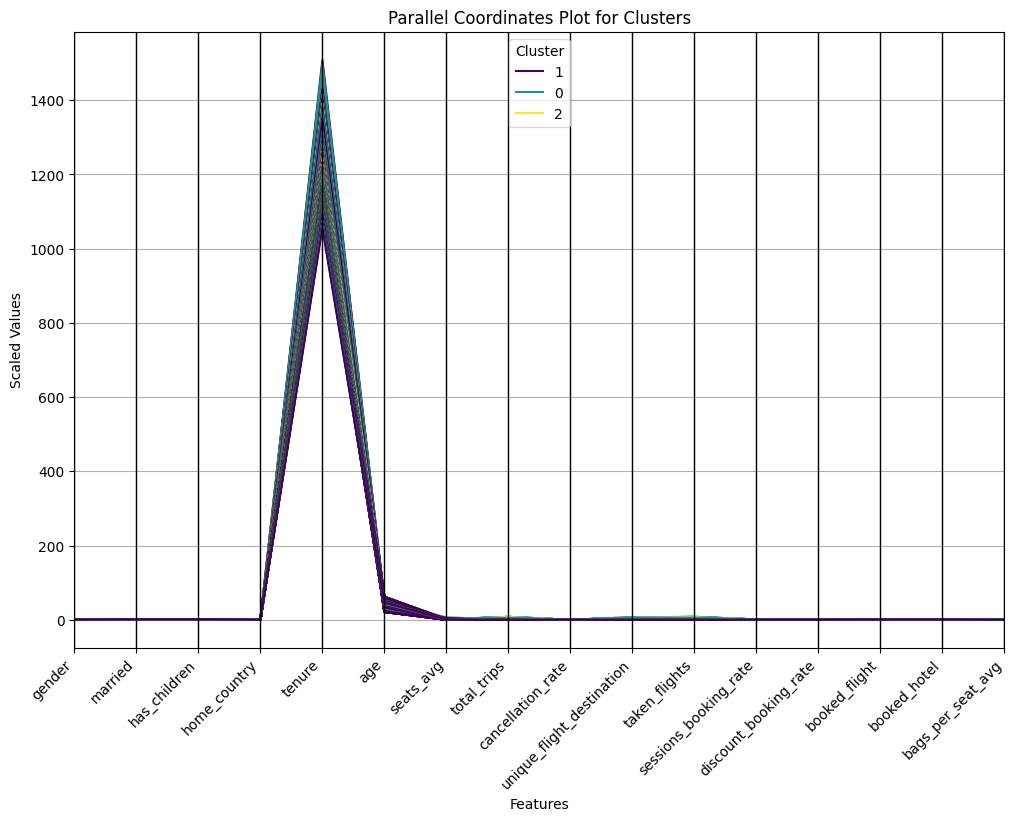

In [261]:
plt.figure(figsize=(12, 8))
parallel_coordinates(users_features, 'cluster', colormap='viridis')
plt.title('Parallel Coordinates Plot for Clusters')
plt.xlabel('Features')
plt.ylabel('Scaled Values')
plt.legend(title='Cluster')
plt.xticks(rotation=45, ha='right')
plt.show()

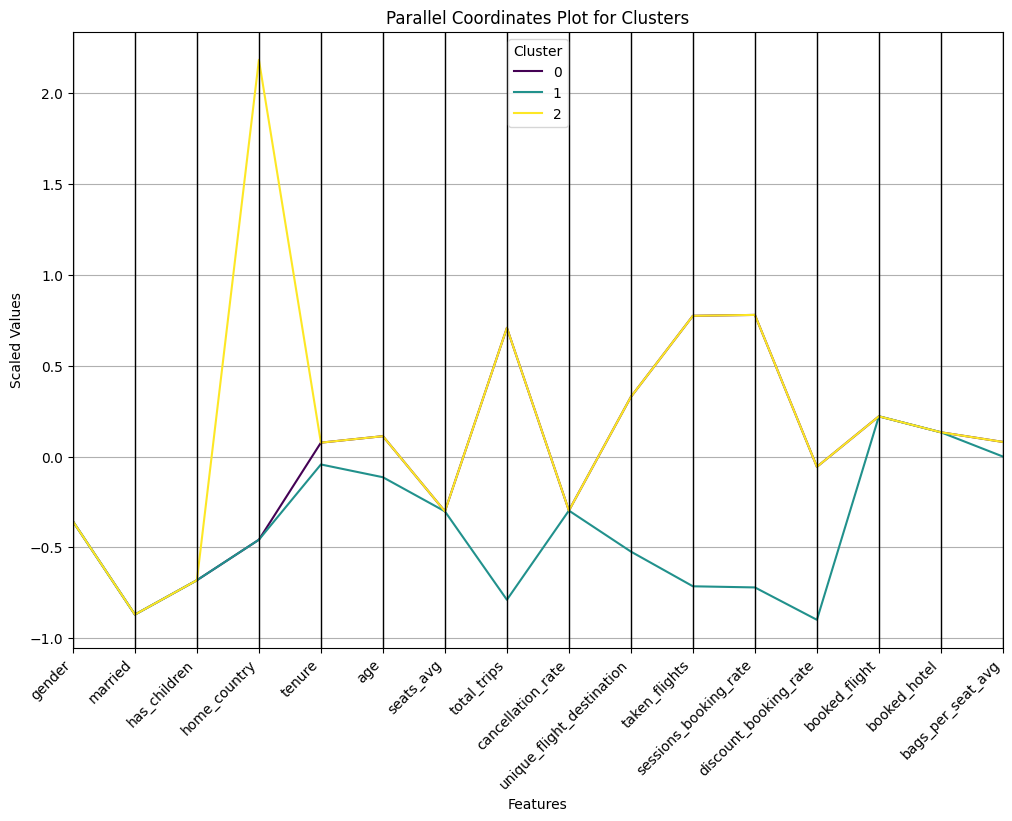

In [263]:
plt.figure(figsize=(12, 8))
parallel_coordinates(scaled_users_features_df.groupby('cluster').median().reset_index(), 'cluster', colormap='viridis')
plt.title('Parallel Coordinates Plot for Clusters')
plt.xlabel('Features')
plt.ylabel('Scaled Values')
plt.legend(title='Cluster')
plt.xticks(rotation=45, ha='right')
plt.show()

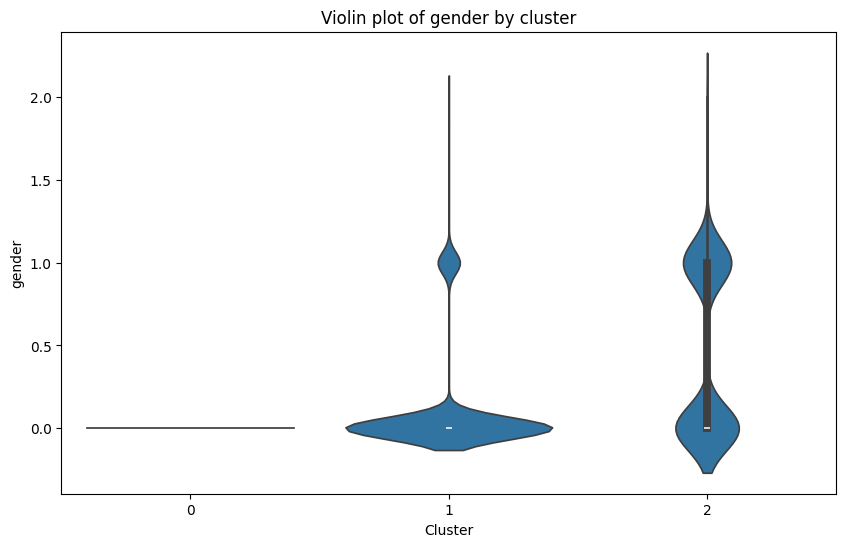

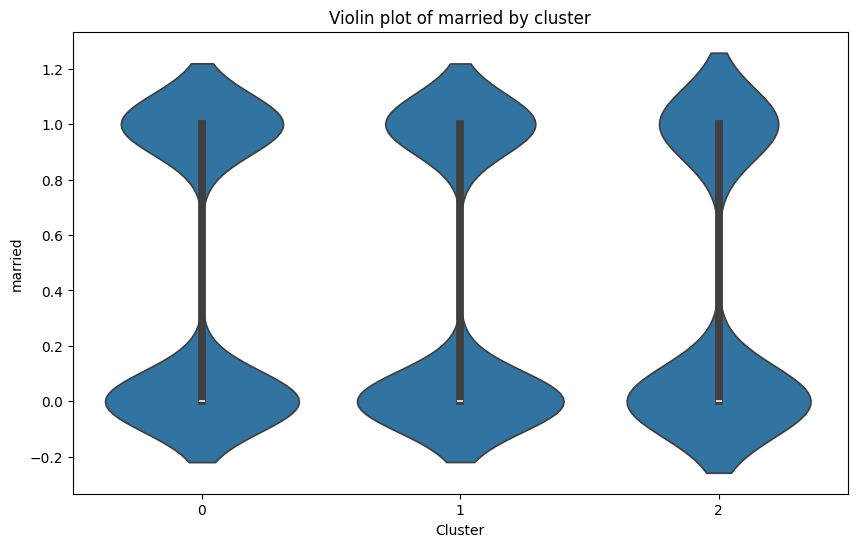

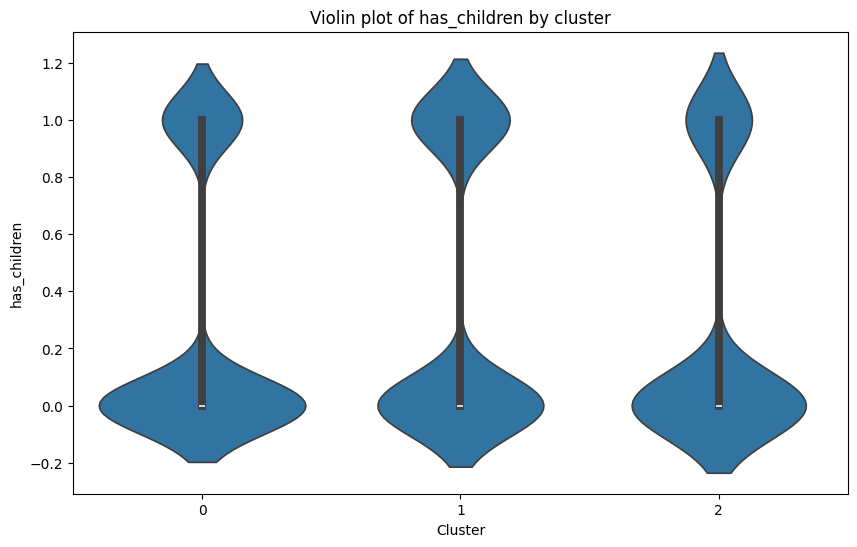

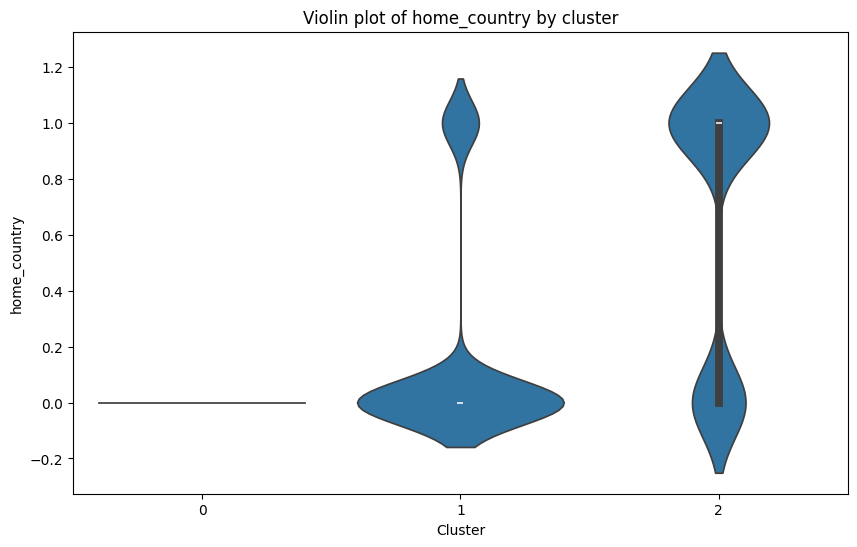

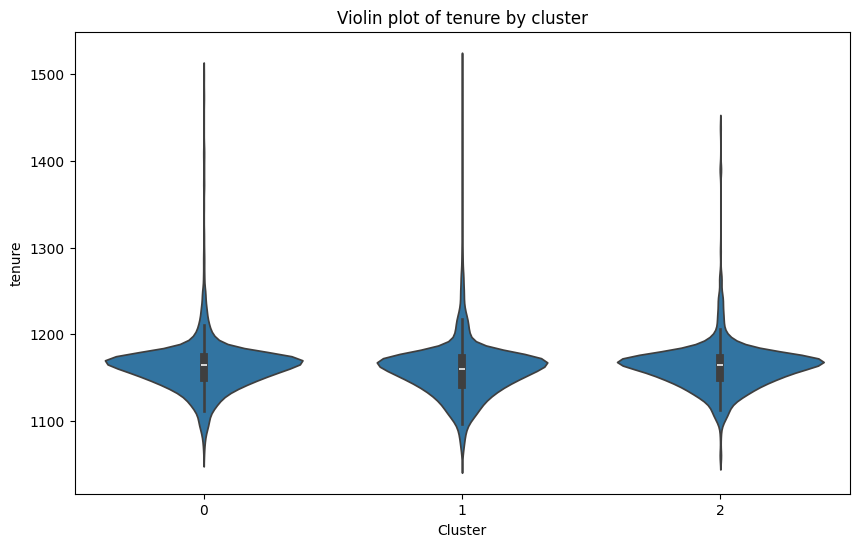

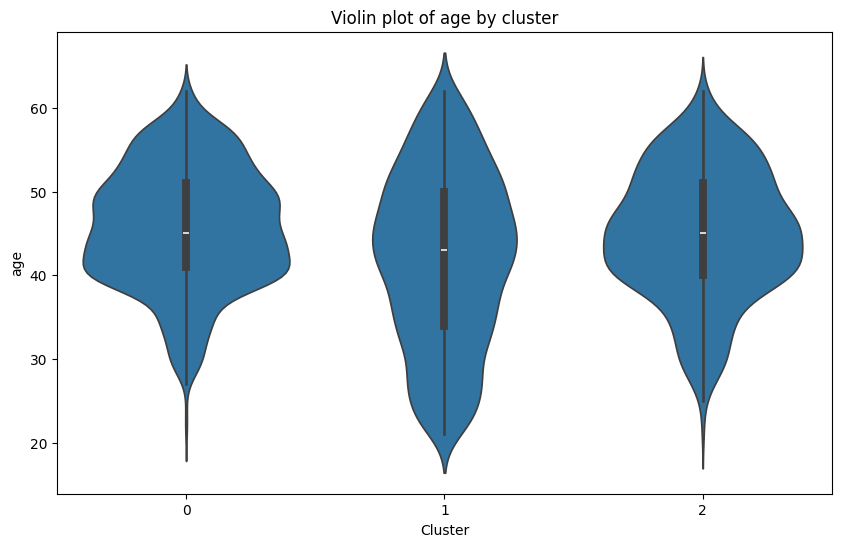

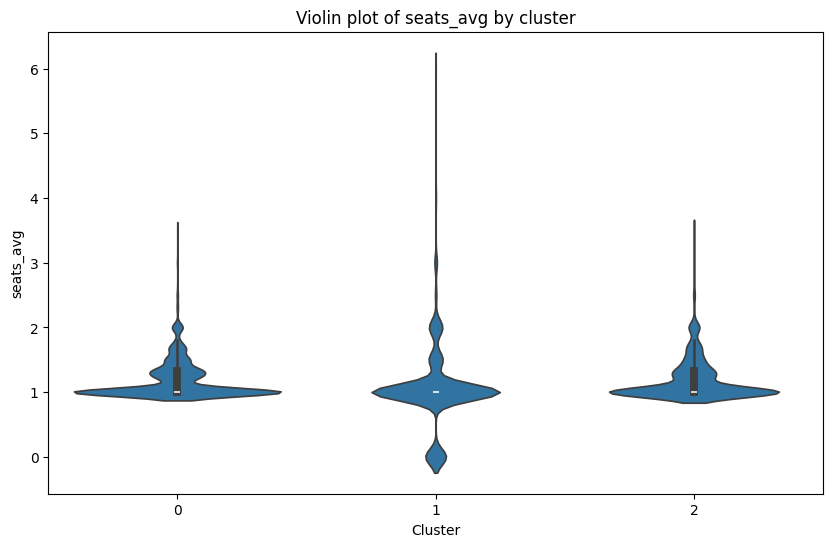

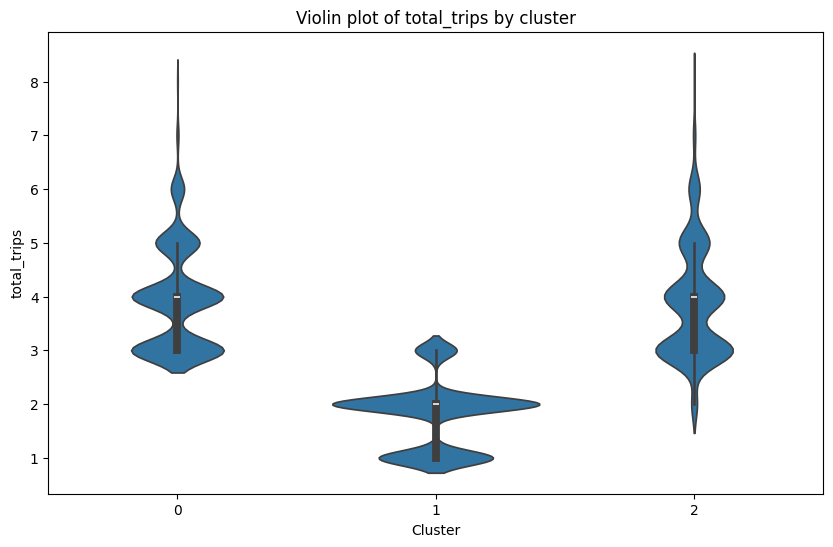

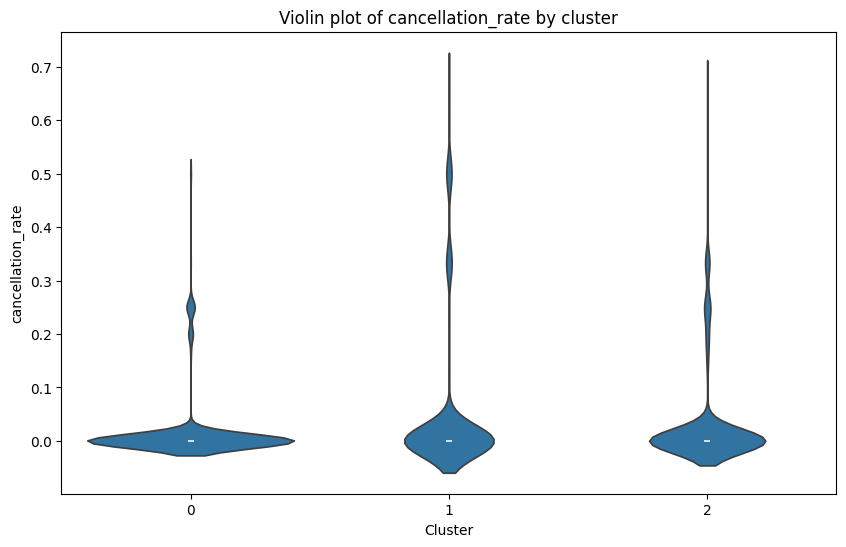

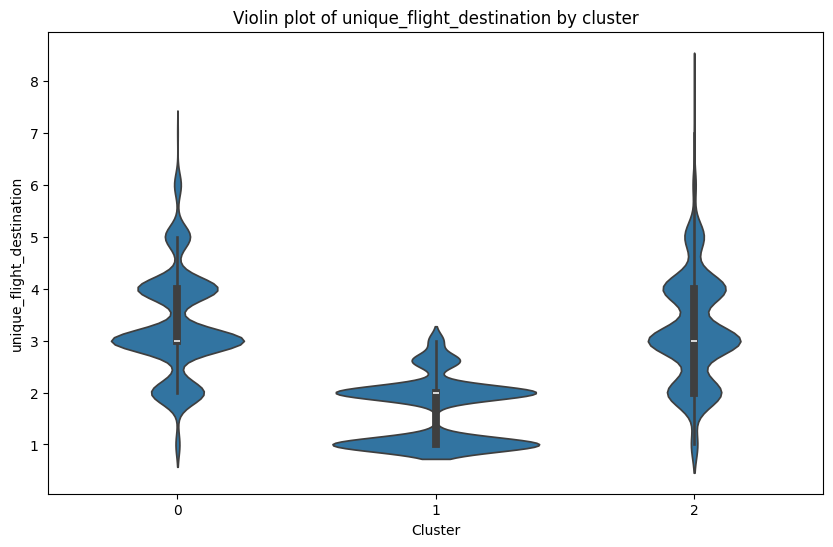

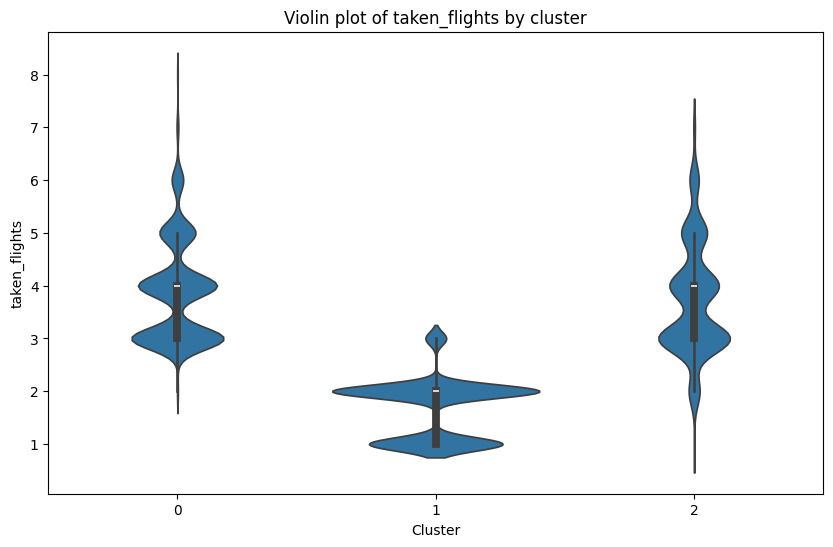

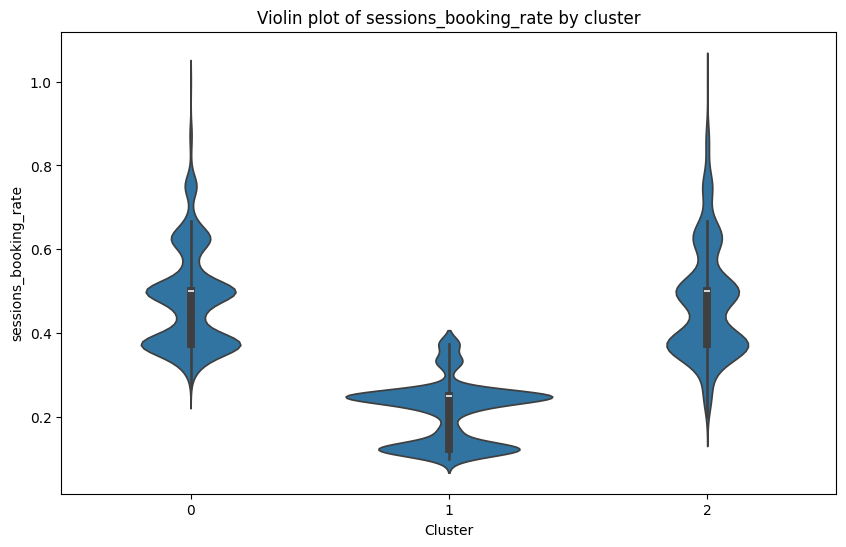

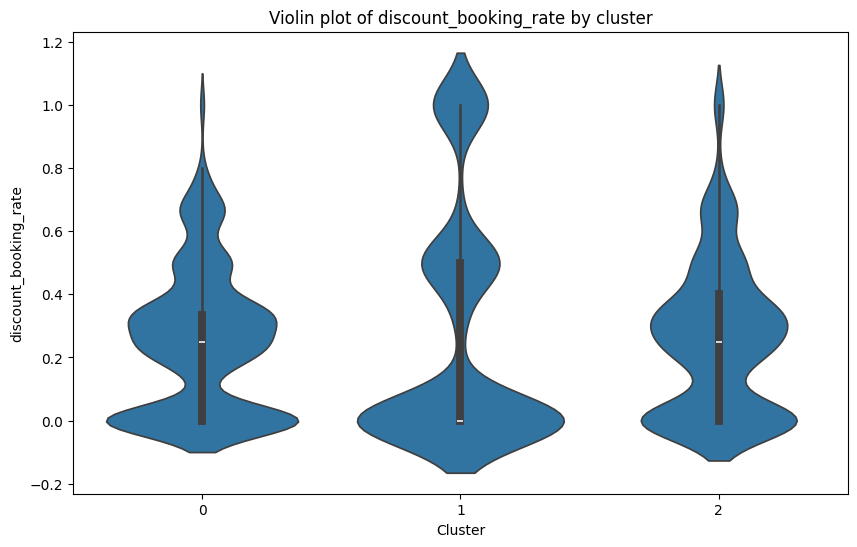

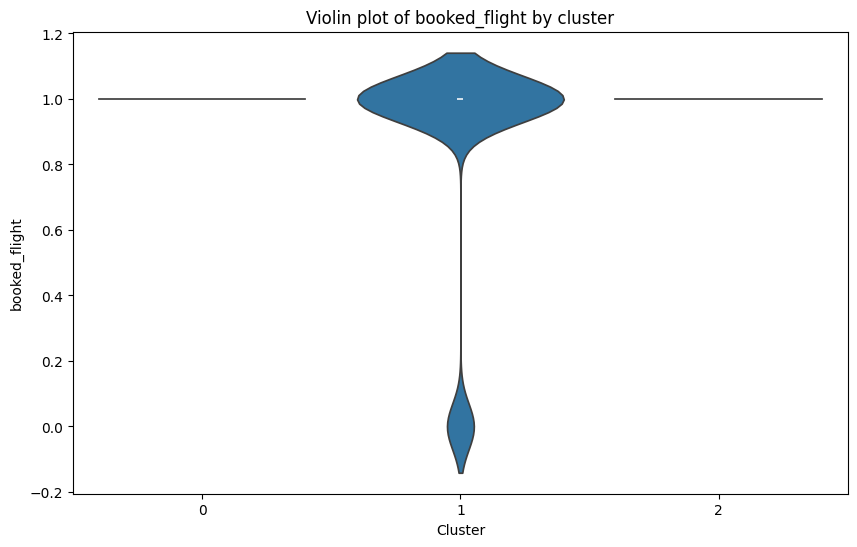

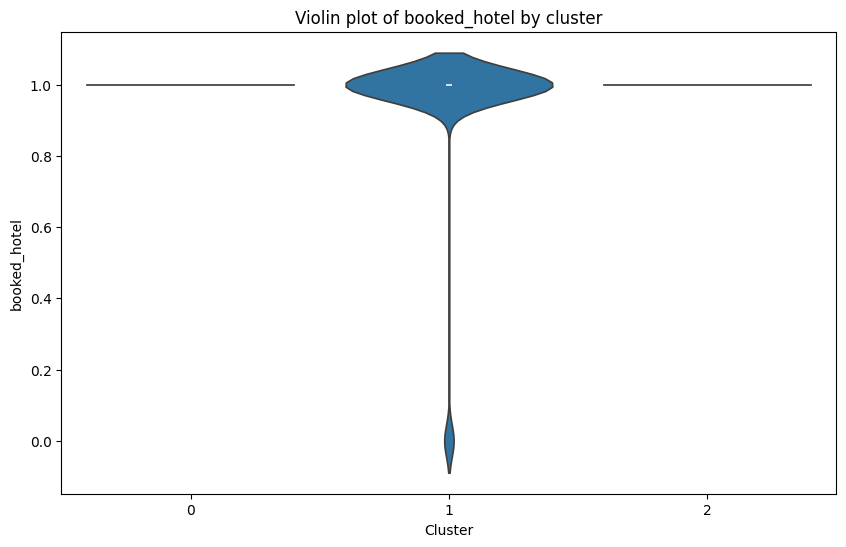

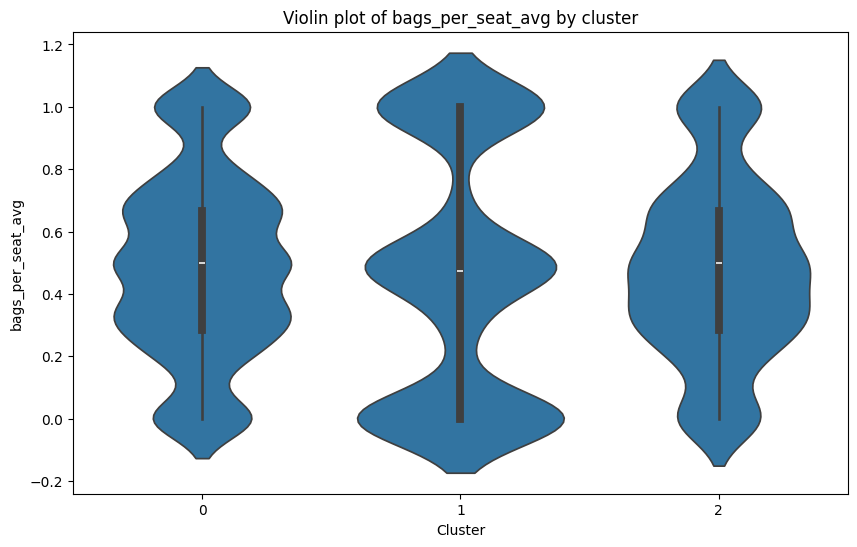

In [264]:
# Violin plots for each feature by cluster
features = users_features.columns[:-1]  # Exclude the cluster column
for feature in features:
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=users_features, x='cluster', y=feature)
    plt.title(f'Violin plot of {feature} by cluster')
    plt.xlabel('Cluster')
    plt.ylabel(feature)
    plt.show()

In [245]:
users_features[["booked_flight", "booked_hotel", "cluster"]].groupby("cluster").value_counts()

cluster  booked_flight  booked_hotel
0        1              1               2404
1        1              1               1921
         0              1                216
         1              0                 81
Name: count, dtype: int64

In [246]:
users_features

,gender,married,has_children,home_country,tenure,age,seats_avg,total_trips,cancellation_rate,unique_flight_destination,taken_flights,sessions_booking_rate,discount_booking_rate,booked_flight,booked_hotel,bags_per_seat_avg,cluster
0,0,1,0,0,1509,54,1.5,2,0.0,2.0,2,0.250,0.0,1,1,0.333333,1
1,0,1,1,0,1499,53,1.0,2,0.0,1.0,2,0.250,0.0,1,1,0.000000,1
2,0,1,0,0,1499,45,1.0,5,0.0,5.0,5,0.625,0.2,1,1,0.400000,0
3,0,0,1,0,1478,53,2.0,5,0.0,3.0,5,0.625,0.6,1,1,0.500000,0
4,0,0,1,1,1438,47,1.0,3,0.0,3.0,3,0.375,0.0,1,1,0.333333,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4617,0,0,0,0,1068,50,1.0,1,0.0,1.0,1,0.125,0.0,1,1,0.000000,1
4618,0,1,1,0,1067,51,1.5,2,0.0,2.0,2,0.250,0.5,1,1,0.000000,1
4619,0,1,1,0,1065,46,1.0,2,0.0,2.0,2,0.250,0.0,1,1,0.000000,1
4620,0,0,0,0,1062,48,1.0,4,0.0,4.0,4,0.500,0.0,1,1,0.500000,0


In [265]:
users_features_w_id = pd.read_csv('data/users_no_group.csv')
users_features_w_id['cluster'] = kmeans.labels_

# Group Creation
0 - Single travelers
1 - low income
2 - Luxurious traveler

In [268]:
users_features_w_id[users_features_w_id['cluster'] == 0].to_csv("data/groups/singles.csv", index=False)
users_features_w_id[users_features_w_id['cluster'] == 1].to_csv("data/groups/low_income.csv", index=False)
users_features_w_id[users_features_w_id['cluster'] == 2].to_csv("data/groups/luxus.csv", index=False)